In [ ]:
import pandas as pd

EXCEL_PATH = "gaitmotion.xlsx"

raw_df = pd.read_excel(EXCEL_PATH, header=0, dtype=str)

lines = raw_df.iloc[:, 0].dropna().astype(str)

df = lines.str.split(",", n=16, expand=True)

df.columns = [
    "AG_X","AG_Y","AG_Z",
    "Acc_X","Acc_Y","Acc_Z",
    "Gravity_X","Gravity_Y","Gravity_Z",
    "RR_X","RR_Y","RR_Z",
    "RV_X","RV_Y","RV_Z",
    "cos","activity"
]

df["activity"] = df["activity"].astype(str).str.strip()


numeric_cols = df.columns[:-1]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df_clean = df.dropna(subset=list(numeric_cols) + ["activity"]).reset_index(drop=True)

print("Raw rows (non-empty):", len(lines))
print("Clean rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print("Unique activities:", df_clean["activity"].nunique())
print("\nActivity distribution:\n", df_clean["activity"].value_counts())

display(df_clean.head(10))

df_clean.to_csv("gaitmotion_cleaned.csv", index=False)
print("\nSaved:", "gaitmotion_cleaned.csv")


Raw rows (non-empty): 483895
Clean rows: 483895
Columns: 17
Unique activities: 6

Activity distribution:
 activity
Walking       90194
Sitting       86574
Running       80447
Standing      79947
Upstairs      74302
Downstairs    72431
Name: count, dtype: int64


,AG_X,AG_Y,AG_Z,Acc_X,Acc_Y,Acc_Z,Gravity_X,Gravity_Y,Gravity_Z,RR_X,RR_Y,RR_Z,RV_X,RV_Y,RV_Z,cos,activity
0,2.10300,-10.078051,0.48195,0.012928,-0.501156,0.773655,2.090072,-9.576895,-0.291705,-0.544362,-0.690113,0.011275,-0.688547,0.204547,-0.335546,0.609485,Downstairs
1,1.94700,-10.311001,-0.70905,-0.143859,-0.736671,-0.347219,2.090500,-9.572949,-0.398576,-0.574200,-0.885912,-0.051562,-0.691788,0.202928,-0.332147,0.608217,Downstairs
2,2.25195,-10.354051,-0.76695,0.162793,-0.782364,-0.332584,2.089157,-9.571687,-0.434366,-0.524150,-0.873263,-0.014300,-0.695132,0.200782,-0.328182,0.607269,Downstairs
3,2.12895,-10.315050,-0.58200,0.045556,-0.744760,-0.092729,2.083394,-9.570291,-0.489271,-0.319825,-0.740437,0.008112,-0.697579,0.199202,-0.325038,0.606673,Downstairs
4,2.08200,-10.420951,-0.82695,0.002480,-0.850770,-0.319362,2.079520,-9.570181,-0.507588,0.097350,-0.623150,-0.035612,-0.698476,0.197974,-0.323439,0.606897,Downstairs
5,1.98105,-10.416000,-0.98205,-0.101426,-0.844907,-0.504690,2.082477,-9.571094,-0.477360,0.808225,-0.275550,-0.144100,-0.698396,0.194842,-0.321401,0.609082,Downstairs
6,1.53495,-10.360950,-0.65400,-0.554122,-0.787799,-0.252818,2.091959,-9.574480,-0.351347,0.995500,-0.276650,-0.173937,-0.696319,0.192151,-0.321190,0.612417,Downstairs
7,1.36995,-10.311001,-0.26100,-0.715813,-0.735183,0.090732,2.100139,-9.576135,-0.239733,1.210550,-0.269363,-0.206937,-0.693250,0.189144,-0.321602,0.616605,Downstairs
8,1.43295,-10.390051,0.19500,-0.672517,-0.813819,0.377180,2.109564,-9.576228,-0.126497,1.207250,-0.189750,-0.214363,-0.689806,0.185906,-0.322284,0.621080,Downstairs
9,1.26000,-10.306050,0.45795,-0.851229,-0.729651,0.533534,2.110117,-9.576892,-0.030437,0.914650,-0.152075,-0.129250,-0.686515,0.183438,-0.322956,0.625097,Downstairs



Saved: gaitmotion_cleaned.csv


In [3]:


import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)


DATA_PATH = "gaitmotion_cleaned.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Unique activities:", df["activity"].nunique())
print(df["activity"].value_counts())


X = df.drop(columns=["activity"])
y = df["activity"].astype(str)

le = LabelEncoder()
y_enc = le.fit_transform(y)

print("\nClasses:", list(le.classes_))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print("\nTrain size:", X_train.shape, "Test size:", X_test.shape)


models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=7))
    ]),
    "Gaussian Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GaussianNB())
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    )
}


results = []

for name, model in models.items():
    print(f"\n {name} ")


    model.fit(X_train, y_train)


    y_pred = model.predict(X_test)


    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")


    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision_weighted": prec,
        "Recall_weighted": rec,
        "F1_weighted": f1
    })

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix shape:", cm.shape)

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n\n MODEL COMPARISON TABLE (sorted by Accuracy) ")
display(results_df)

results_df.to_csv("model_results.csv", index=False)
print("\nSaved: model_results.csv")


Dataset shape: (483895, 17)
Columns: ['AG_X', 'AG_Y', 'AG_Z', 'Acc_X', 'Acc_Y', 'Acc_Z', 'Gravity_X', 'Gravity_Y', 'Gravity_Z', 'RR_X', 'RR_Y', 'RR_Z', 'RV_X', 'RV_Y', 'RV_Z', 'cos', 'activity']
Unique activities: 6
activity
Walking       90194
Sitting       86574
Running       80447
Standing      79947
Upstairs      74302
Downstairs    72431
Name: count, dtype: int64

Classes: ['Downstairs', 'Running', 'Sitting', 'Standing', 'Upstairs', 'Walking']

Train size: (387116, 16) Test size: (96779, 16)

 Logistic Regression 
Accuracy : 0.4188
Precision: 0.4147
Recall   : 0.4188
F1-Score : 0.4114

Classification Report:

              precision    recall  f1-score   support

  Downstairs       0.37      0.41      0.39     14486
     Running       0.39      0.35      0.37     16090
     Sitting       0.51      0.60      0.55     17315
    Standing       0.42      0.55      0.48     15989
    Upstairs       0.41      0.25      0.31     14860
     Walking       0.37      0.33      0.35     18039

,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
4,Extra Trees,0.984924,0.984944,0.984924,0.984918
3,Random Forest,0.972928,0.972949,0.972928,0.972912
1,KNN,0.957057,0.957222,0.957057,0.957050
2,Gaussian Naive Bayes,0.642360,0.653324,0.642360,0.640824
0,Logistic Regression,0.418758,0.414705,0.418758,0.411389



Saved: model_results.csv


In [4]:
import os
import matplotlib.pyplot as plt

OUT_DIR = "/content/results_figures"
os.makedirs(OUT_DIR, exist_ok=True)
print("Saving figures to:", OUT_DIR)

def save_fig(filename):
    path = os.path.join(OUT_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)
    plt.show()
    plt.close()


Saving figures to: /content/results_figures


Saved: /content/results_figures/CM_Logistic_Regression.png


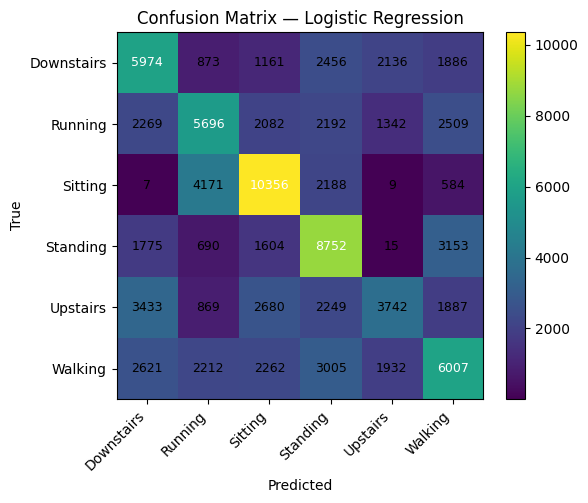

Saved: /content/results_figures/CM_KNN.png


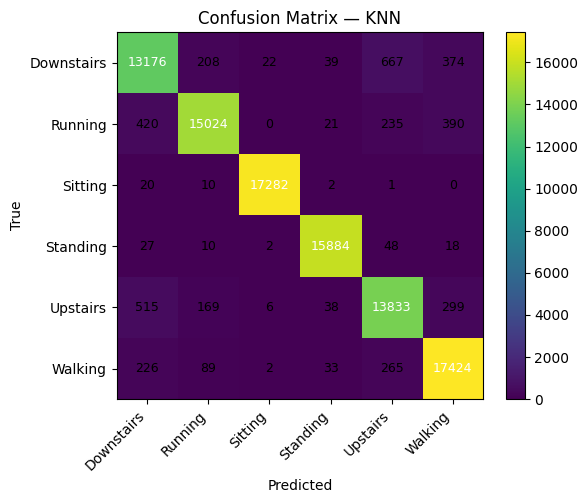

Saved: /content/results_figures/CM_Gaussian_Naive_Bayes.png


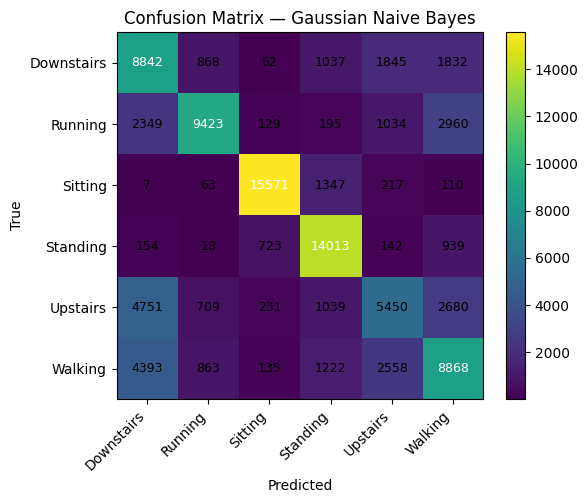

Saved: /content/results_figures/CM_Random_Forest.png


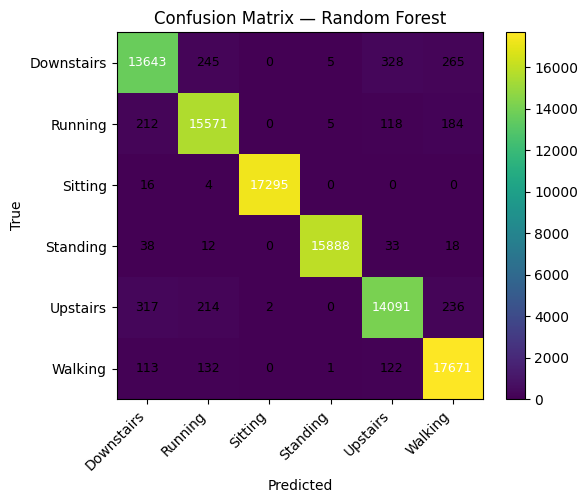

Saved: /content/results_figures/CM_Extra_Trees.png


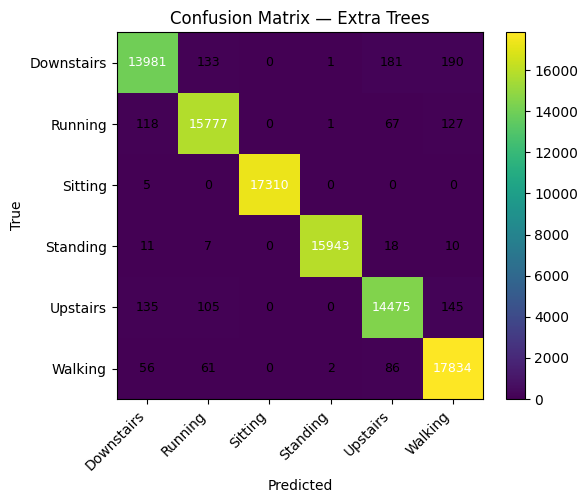

In [5]:
from sklearn.metrics import confusion_matrix
import numpy as np

class_names = le.classes_
n_classes = len(class_names)

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(n_classes), class_names, rotation=45, ha="right")
    plt.yticks(range(n_classes), class_names)
    plt.colorbar()

    for i in range(n_classes):
        for j in range(n_classes):
            plt.text(
                j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=9
            )

    plt.tight_layout()
    save_fig(f"CM_{name.replace(' ', '_')}.png")

Saved: /content/results_figures/ROC_Logistic_Regression.png


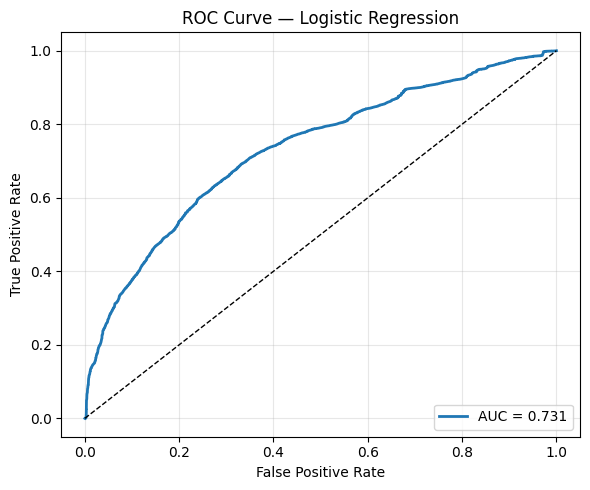

Saved: /content/results_figures/ROC_KNN.png


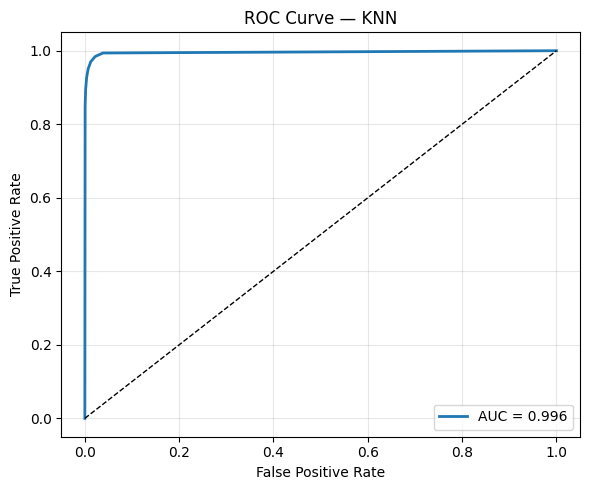

Saved: /content/results_figures/ROC_Gaussian_Naive_Bayes.png


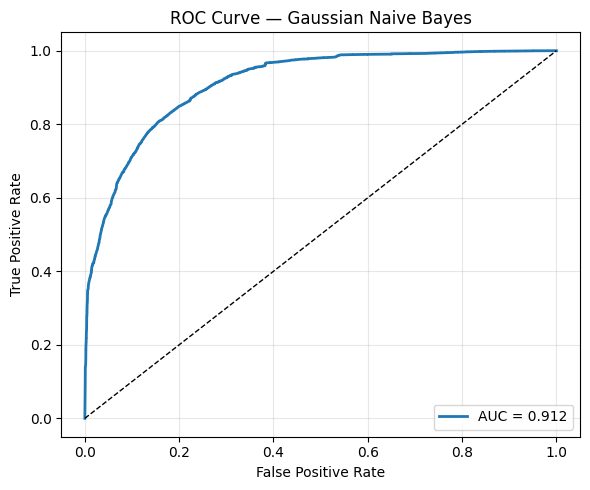

Saved: /content/results_figures/ROC_Random_Forest.png


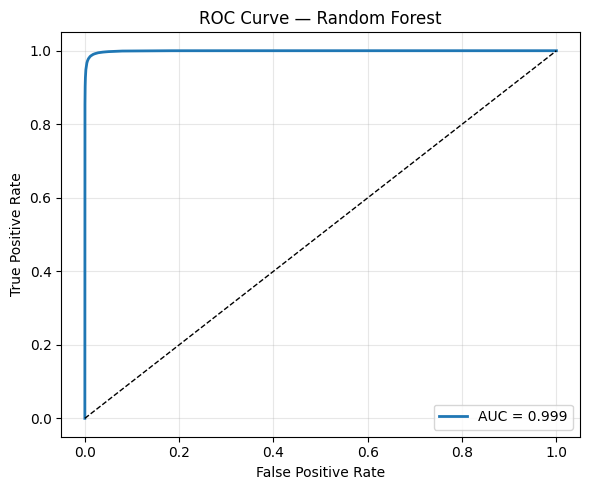

Saved: /content/results_figures/ROC_Extra_Trees.png


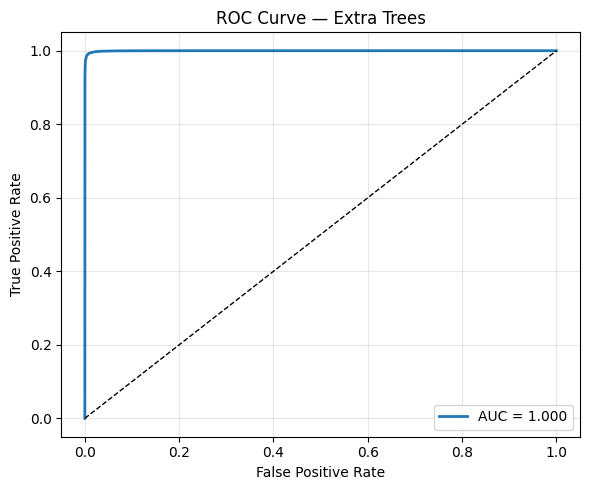

Saved: /content/results_figures/ROC_All_Models.png


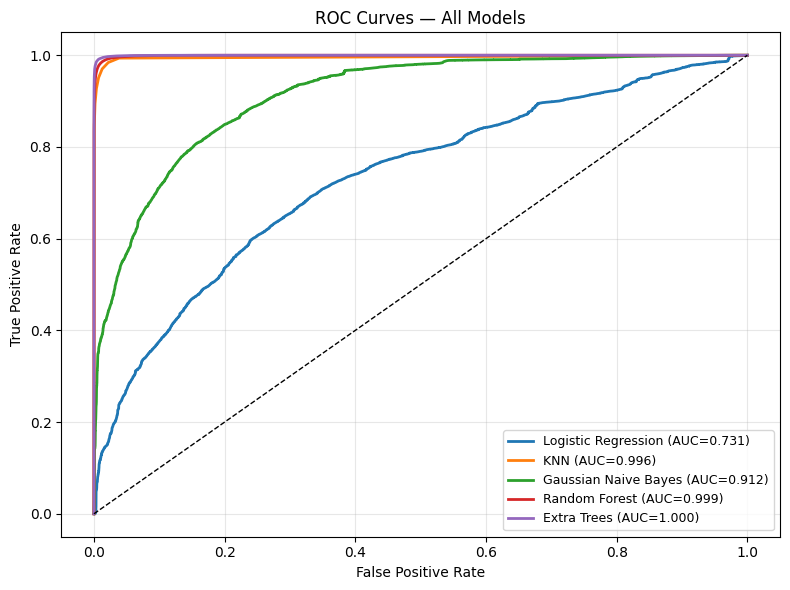

In [6]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=range(n_classes))

for name, model in models.items():
    if not hasattr(model, "predict_proba"):
        continue

    y_score = model.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.title(f"ROC Curve — {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    save_fig(f"ROC_{name.replace(' ', '_')}.png")

plt.figure(figsize=(8, 6))
for name, model in models.items():
    if not hasattr(model, "predict_proba"):
        continue

    y_score = model.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.title("ROC Curves — All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=9, loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

save_fig("ROC_All_Models.png")


Saved: /content/results_figures/FI_ExtraTrees_AllFeatures.png


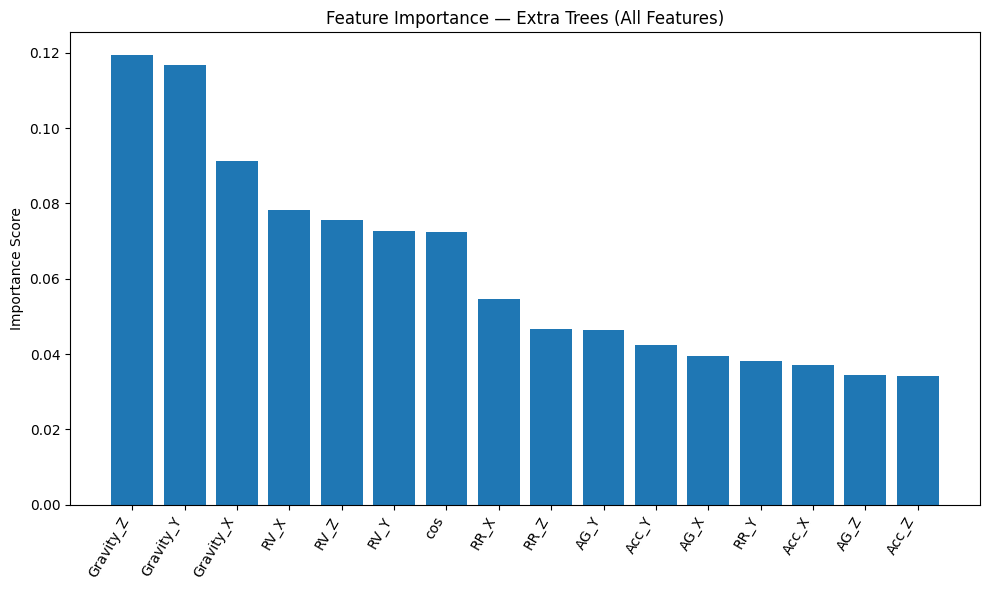

Saved: /content/results_figures/FI_ExtraTrees_Top10.png


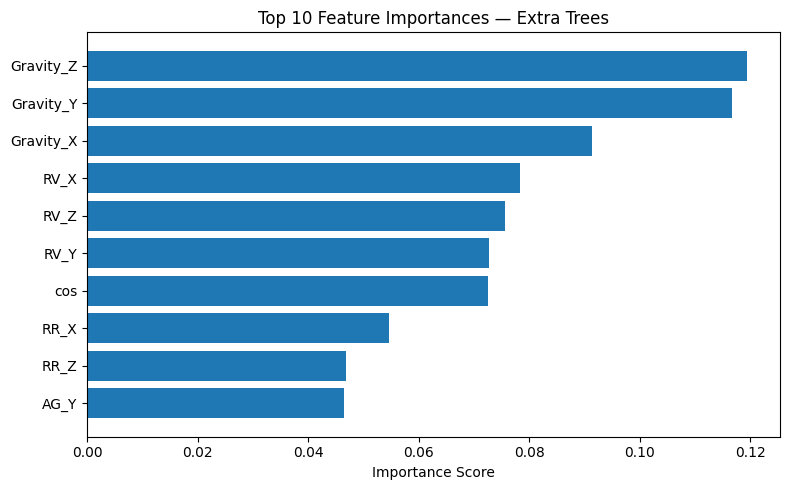

In [7]:
import numpy as np

best_model = models["Extra Trees"]
importances = best_model.feature_importances_
feature_names = X.columns.to_numpy()

idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[idx])
plt.xticks(range(len(importances)), feature_names[idx], rotation=60, ha="right")
plt.title("Feature Importance — Extra Trees (All Features)")
plt.ylabel("Importance Score")
plt.tight_layout()

save_fig("FI_ExtraTrees_AllFeatures.png")

top_k = 10
idx_top = idx[:top_k]

plt.figure(figsize=(8, 5))
plt.barh(range(top_k), importances[idx_top][::-1])
plt.yticks(range(top_k), feature_names[idx_top][::-1])
plt.title("Top 10 Feature Importances — Extra Trees")
plt.xlabel("Importance Score")
plt.tight_layout()

save_fig("FI_ExtraTrees_Top10.png")
